<a href="https://colab.research.google.com/github/amina489/mathematical-modeling/blob/main/mathematical_modeling_project_using_SIR_framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== SIR Disease Spread Model ===
Enter total population (e.g. 1000): 2500
Enter initial infected individuals (e.g. 1): 27
Enter initial recovered individuals (e.g. 0): 3
Enter infection rate (β, e.g. 0.3): 2
Enter recovery rate (γ, e.g. 0.1): 0.3
Enter vaccination rate (0-1, e.g. 0.3): 0.4


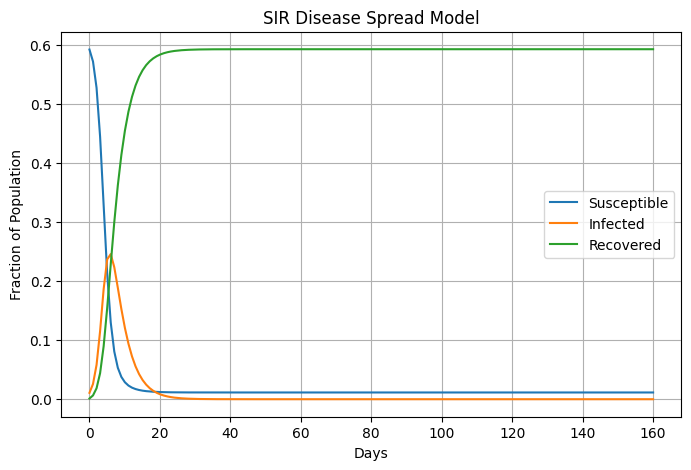

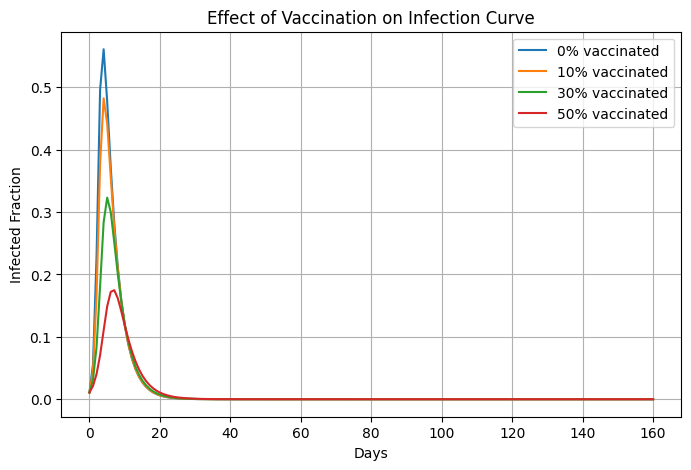

Vaccination achieved approximately 68.84% reduction in peak infections.


In [3]:

#  Disease Spread & Neural Modeling Interactive Simulation

# Installing required libraries
!pip install numpy matplotlib scipy pandas -q

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import pandas as pd

#  PROJECT= Disease Spread Modeling (SIR Framework)

print("=== SIR Disease Spread Model ===")

# --- Step 1: User Inputs ---
N = int(input("Enter total population (e.g. 1000): "))
I0 = int(input("Enter initial infected individuals (e.g. 1): "))
R0 = int(input("Enter initial recovered individuals (e.g. 0): "))
beta = float(input("Enter infection rate (β, e.g. 0.3): "))
gamma = float(input("Enter recovery rate (γ, e.g. 0.1): "))
vaccination_rate = float(input("Enter vaccination rate (0-1, e.g. 0.3): "))

#  Step 2: Define SIR Model
def SIR_model(y, t, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I
    dIdt = beta * S * I - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# Step 3: Solve Model
S0 = (1 - vaccination_rate) * (N - I0 - R0)
t = np.linspace(0, 160, 160)
y0 = [S0/N, I0/N, R0/N]
solution = odeint(SIR_model, y0, t, args=(beta, gamma))
S, I, R = solution.T

# Step 4: Plot Infection Trends
plt.figure(figsize=(8,5))
plt.plot(t, S, label='Susceptible')
plt.plot(t, I, label='Infected')
plt.plot(t, R, label='Recovered')
plt.xlabel('Days')
plt.ylabel('Fraction of Population')
plt.title('SIR Disease Spread Model')
plt.legend()
plt.grid()
plt.show()

# Step 5: Vaccination Effect Analysis
vaccination_rates = [0, 0.1, 0.3, 0.5]
max_infections = []

plt.figure(figsize=(8,5))
for v in vaccination_rates:
    S0_vacc = (1 - v) * (N - I0 - R0)
    y0_v = [S0_vacc/N, I0/N, R0/N]
    sol = odeint(SIR_model, y0_v, t, args=(beta, gamma))
    S, I, R = sol.T
    plt.plot(t, I, label=f'{int(v*100)}% vaccinated')
    max_infections.append(np.max(I))

plt.xlabel('Days')
plt.ylabel('Infected Fraction')
plt.title('Effect of Vaccination on Infection Curve')
plt.legend()
plt.grid()
plt.show()

# Step 6: Infection Reduction Analysis
reduction = 100 * (1 - max_infections[-1] / max_infections[0])

print(f"Vaccination achieved approximately {reduction:.2f}% reduction in peak infections.")
